# 📊 TP3 - Comparação de Modelos: KNN vs Random Forest
## Dataset: Breast Cancer Wisconsin
### Estratégia: Holdout + Validação Cruzada

## 1. Importação das Bibliotecas

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV
)
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

## 2. Classe para Gerenciamento de Experimentos

In [15]:
class GerenciadorExperimentos:
    def __init__(self, dados_x, dados_y, nomes_classes, seed=42):
        self.dados_x = dados_x
        self.dados_y = dados_y
        self.nomes_classes = nomes_classes
        self.seed = seed
        self.escalonador = StandardScaler()
        self.resultados_cv = {}
        self.resultados_finais = {}

    def dividir_dados_holdout(self, proporcao_teste=0.4):
        """Estratégia: 60% treino+validação / 40% teste final"""
        self.x_treino_val, self.x_teste_final, self.y_treino_val, self.y_teste_final = train_test_split(
            self.dados_x, self.dados_y,
            test_size=proporcao_teste,
            random_state=self.seed,
            stratify=self.dados_y
        )

        # Normalização
        self.x_treino_val_norm = self.escalonador.fit_transform(self.x_treino_val)
        self.x_teste_final_norm = self.escalonador.transform(self.x_teste_final)

    def executar_validacao_cruzada(self, modelo, nome_modelo, num_folds=5):
        """Executa validação cruzada estratificada"""
        cv_strategy = StratifiedKFold(n_splits=num_folds, shuffle=True, random_state=self.seed)

        # Métricas para cada fold
        metricas = ['accuracy', 'precision', 'recall', 'f1']
        scores = {}

        for metrica in metricas:
            scores[metrica] = cross_val_score(
                modelo, self.x_treino_val_norm, self.y_treino_val,
                cv=cv_strategy, scoring=metrica
            )

        # Armazenar resultados
        self.resultados_cv[nome_modelo] = {
            'modelo': modelo,
            'scores': scores,
            'medias': {metrica: np.mean(valores) for metrica, valores in scores.items()},
            'desvios': {metrica: np.std(valores) for metrica, valores in scores.items()}
        }

        return scores

    def treinar_modelo_final(self, modelo, nome_modelo):
        """Treina modelo com todos os dados de treino+validação"""
        modelo_final = modelo
        modelo_final.fit(self.x_treino_val_norm, self.y_treino_val)

        # Predições no conjunto de teste final
        predicoes = modelo_final.predict(self.x_teste_final_norm)

        # Calcular métricas finais
        self.resultados_finais[nome_modelo] = {
            'modelo': modelo_final,
            'predicoes': predicoes,
            'accuracy': accuracy_score(self.y_teste_final, predicoes),
            'precision': precision_score(self.y_teste_final, predicoes),
            'recall': recall_score(self.y_teste_final, predicoes),
            'f1': f1_score(self.y_teste_final, predicoes)
        }

        return modelo_final, predicoes

    def comparar_modelos_cv(self):
        """Compara performance na validação cruzada"""
        df_comparacao = pd.DataFrame()

        for nome_modelo, resultados in self.resultados_cv.items():
            for metrica, media in resultados['medias'].items():
                desvio = resultados['desvios'][metrica]
                df_comparacao.loc[nome_modelo, f'{metrica}_media'] = media
                df_comparacao.loc[nome_modelo, f'{metrica}_desvio'] = desvio

        return df_comparacao

    def gerar_relatorio_completo(self):
        """Gera relatório completo da comparação"""
        print("="*80)
        print(" 📋 RELATÓRIO COMPARATIVO DE MODELOS")
        print("="*80)

        # Resultados da Validação Cruzada
        print("\n🔄 RESULTADOS DA VALIDAÇÃO CRUZADA (5-Fold)")
        print("-"*50)

        for nome_modelo, resultados in self.resultados_cv.items():
            print(f"\n📊 {nome_modelo.upper()}")
            for metrica, media in resultados['medias'].items():
                desvio = resultados['desvios'][metrica]
                print(f"  {metrica.capitalize():12}: {media:.4f} (±{desvio:.4f})")

        # Resultados Finais
        print(f"\n🎯 RESULTADOS NO TESTE FINAL (Holdout)")
        print("-"*50)

        for nome_modelo, resultados in self.resultados_finais.items():
            print(f"\n📈 {nome_modelo.upper()}")
            for metrica in ['accuracy', 'precision', 'recall', 'f1']:
                valor = resultados[metrica]
                print(f"  {metrica.capitalize():12}: {valor:.4f}")

## 3. Carregamento e Preparação dos Dados

In [16]:
# Carregar dataset
dados_cancer = load_breast_cancer()
x_completo = dados_cancer.data
y_completo = dados_cancer.target
nomes_features = dados_cancer.feature_names
nomes_classes = dados_cancer.target_names

print(f"📋 Dataset Breast Cancer Wisconsin")
print(f"    • Amostras: {x_completo.shape[0]}")
print(f"    • Features: {x_completo.shape[1]}")
print(f"    • Classes: {nomes_classes}")
print(f"    • Distribuição: Maligno={np.sum(y_completo==1)}, Benigno={np.sum(y_completo==0)}")

📋 Dataset Breast Cancer Wisconsin
    • Amostras: 569
    • Features: 30
    • Classes: ['malignant' 'benign']
    • Distribuição: Maligno=357, Benigno=212


## 4. Configuração dos Modelos

In [17]:
# Inicializar o gerenciador de experimentos
gerenciador = GerenciadorExperimentos(x_completo, y_completo, nomes_classes)

# Dividir dados: 60% treino+validação / 40% teste final
gerenciador.dividir_dados_holdout(proporcao_teste=0.4)

print(f"📊 Divisão dos Dados:")
print(f"    • Treino+Validação: {gerenciador.x_treino_val.shape[0]} amostras")
print(f"    • Teste Final: {gerenciador.x_teste_final.shape[0]} amostras")

📊 Divisão dos Dados:
    • Treino+Validação: 341 amostras
    • Teste Final: 228 amostras


## 5. Modelo Baseline: K-Nearest Neighbors (KNN)

In [18]:
print("🔧 Configurando KNN (Modelo Baseline)...")

# Otimização de hiperparâmetros para KNN
parametros_knn = {'n_neighbors': range(3, 21, 2)}
knn_base = KNeighborsClassifier()
grid_knn = GridSearchCV(knn_base, parametros_knn, cv=5, scoring='f1')
grid_knn.fit(gerenciador.x_treino_val_norm, gerenciador.y_treino_val)

melhor_knn = grid_knn.best_estimator_
print(f"    ✅ Melhor K para KNN: {melhor_knn.n_neighbors}")

# Validação cruzada do KNN
gerenciador.executar_validacao_cruzada(melhor_knn, 'KNN')

🔧 Configurando KNN (Modelo Baseline)...
    ✅ Melhor K para KNN: 3


{'accuracy': array([0.95652174, 0.98529412, 0.95588235, 0.95588235, 0.97058824]),
 'precision': array([0.95454545, 0.97727273, 0.95454545, 0.93478261, 0.95454545]),
 'recall': array([0.97674419, 1.        , 0.97674419, 1.        , 1.        ]),
 'f1': array([0.96551724, 0.98850575, 0.96551724, 0.96629213, 0.97674419])}

## 6. Modelo Candidato: Random Forest

In [6]:
print("🌲 Configurando Random Forest (Modelo Candidato)...")

# Otimização de hiperparâmetros para Random Forest
parametros_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

rf_base = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(rf_base, parametros_rf, cv=3, scoring='f1', n_jobs=-1)
grid_rf.fit(gerenciador.x_treino_val_norm, gerenciador.y_treino_val)

melhor_rf = grid_rf.best_estimator_
print(f"    ✅ Melhores parâmetros Random Forest:")
print(f"       • n_estimators: {melhor_rf.n_estimators}")
print(f"       • max_depth: {melhor_rf.max_depth}")
print(f"       • min_samples_split: {melhor_rf.min_samples_split}")

# Validação cruzada do Random Forest
gerenciador.executar_validacao_cruzada(melhor_rf, 'Random Forest')

🌲 Configurando Random Forest (Modelo Candidato)...
    ✅ Melhores parâmetros Random Forest:
       • n_estimators: 200
       • max_depth: 10
       • min_samples_split: 2


{'accuracy': array([0.98550725, 0.98529412, 0.98529412, 0.92647059, 0.95588235]),
 'precision': array([1.        , 0.97727273, 0.97727273, 0.93181818, 0.97560976]),
 'recall': array([0.97674419, 1.        , 1.        , 0.95348837, 0.95238095]),
 'f1': array([0.98823529, 0.98850575, 0.98850575, 0.94252874, 0.96385542])}

## 7. Análise da Validação Cruzada

📊 COMPARAÇÃO NA VALIDAÇÃO CRUZADA
               accuracy_media  accuracy_desvio  precision_media  \
KNN                    0.9648           0.0117           0.9551   
Random Forest          0.9677           0.0236           0.9724   

               precision_desvio  recall_media  recall_desvio  f1_media  \
KNN                      0.0135        0.9907         0.0114    0.9725   
Random Forest            0.0222        0.9765         0.0211    0.9743   

               f1_desvio  
KNN               0.0091  
Random Forest     0.0185  


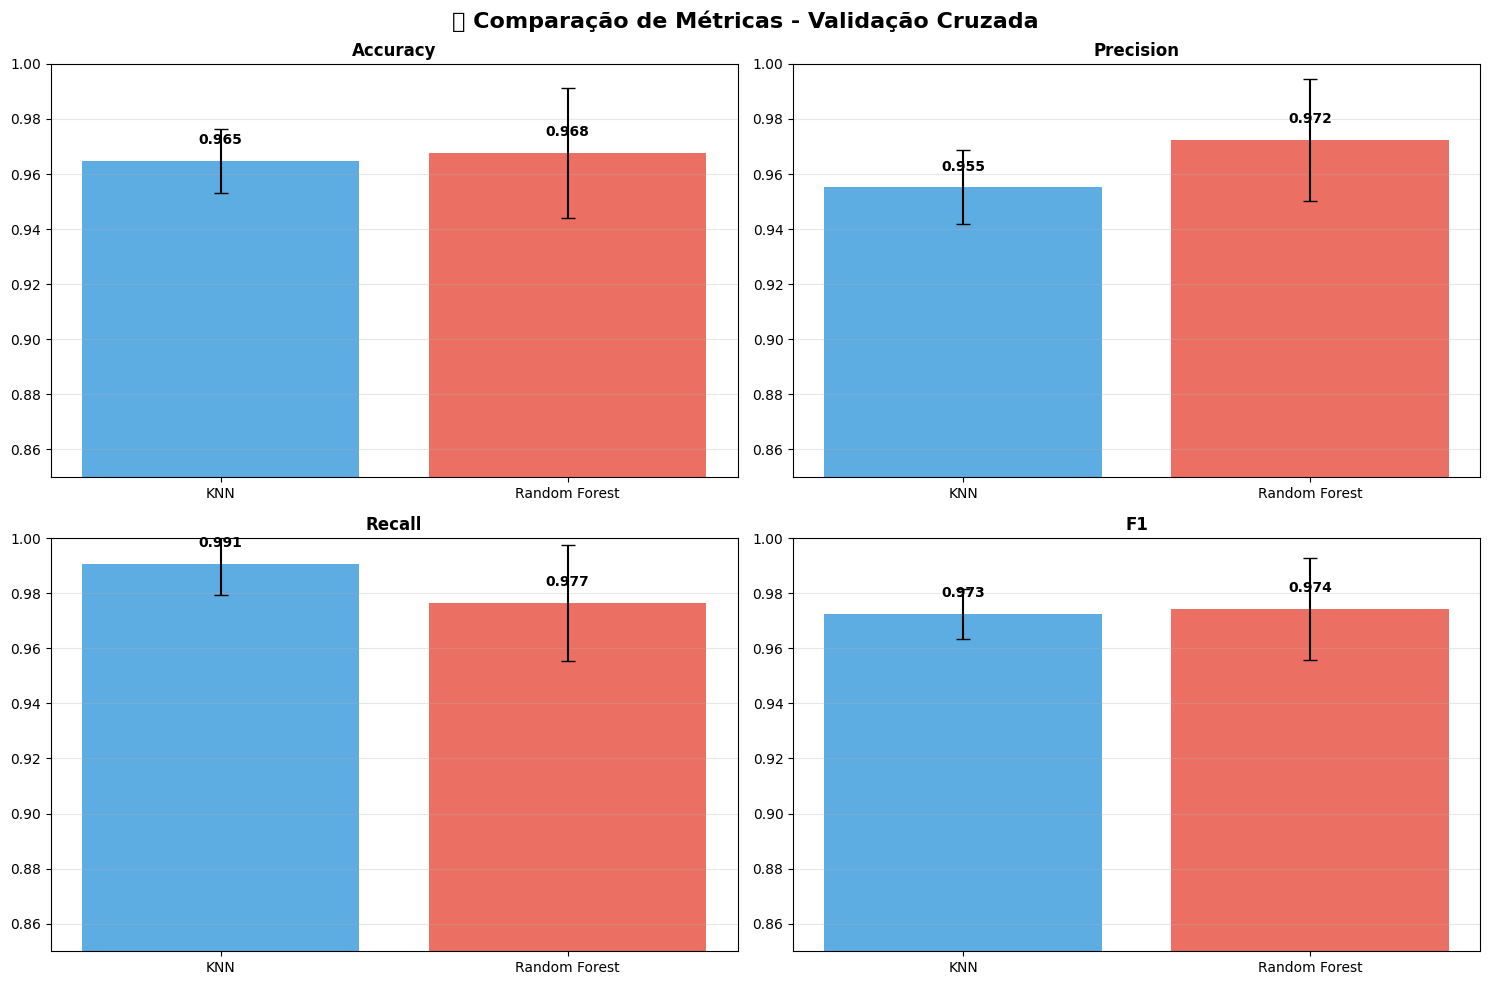

In [7]:
# Comparação dos resultados da validação cruzada
df_cv = gerenciador.comparar_modelos_cv()
print("📊 COMPARAÇÃO NA VALIDAÇÃO CRUZADA")
print("="*60)
print(df_cv.round(4))

# Visualização dos resultados da CV
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('📊 Comparação de Métricas - Validação Cruzada', fontsize=16, fontweight='bold')

metricas = ['accuracy', 'precision', 'recall', 'f1']
cores = ['#3498db', '#e74c3c']

for i, metrica in enumerate(metricas):
    ax = axes[i//2, i%2]

    modelos = list(gerenciador.resultados_cv.keys())
    valores = [gerenciador.resultados_cv[modelo]['medias'][metrica] for modelo in modelos]
    erros = [gerenciador.resultados_cv[modelo]['desvios'][metrica] for modelo in modelos]

    barras = ax.bar(modelos, valores, yerr=erros, capsize=5, color=cores, alpha=0.8)
    ax.set_title(f'{metrica.capitalize()}', fontweight='bold')
    ax.set_ylim(0.85, 1.0)
    ax.grid(axis='y', alpha=0.3)

    # Adicionar valores nas barras
    for barra, valor in zip(barras, valores):
        altura = barra.get_height()
        ax.text(barra.get_x() + barra.get_width()/2., altura + 0.005,
                f'{valor:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Treinamento Final e Teste Holdout

In [8]:
print("🎯 Executando Treinamento Final e Teste Holdout...")

# Treinar modelos finais
modelo_knn_final, pred_knn = gerenciador.treinar_modelo_final(melhor_knn, 'KNN')
modelo_rf_final, pred_rf = gerenciador.treinar_modelo_final(melhor_rf, 'Random Forest')

# Relatório completo
gerenciador.gerar_relatorio_completo()

🎯 Executando Treinamento Final e Teste Holdout...
 📋 RELATÓRIO COMPARATIVO DE MODELOS

🔄 RESULTADOS DA VALIDAÇÃO CRUZADA (5-Fold)
--------------------------------------------------

📊 KNN
  Accuracy    : 0.9648 (±0.0117)
  Precision   : 0.9551 (±0.0135)
  Recall      : 0.9907 (±0.0114)
  F1          : 0.9725 (±0.0091)

📊 RANDOM FOREST
  Accuracy    : 0.9677 (±0.0236)
  Precision   : 0.9724 (±0.0222)
  Recall      : 0.9765 (±0.0211)
  F1          : 0.9743 (±0.0185)

🎯 RESULTADOS NO TESTE FINAL (Holdout)
--------------------------------------------------

📈 KNN
  Accuracy    : 0.9561
  Precision   : 0.9524
  Recall      : 0.9790
  F1          : 0.9655

📈 RANDOM FOREST
  Accuracy    : 0.9474
  Precision   : 0.9580
  Recall      : 0.9580
  F1          : 0.9580


## 9. Análise Estatística de Significância

In [9]:
def teste_significancia_cv(resultados_cv, metrica='f1'):
    """Testa significância estatística entre modelos na CV"""
    scores_knn = resultados_cv['KNN']['scores'][metrica]
    scores_rf = resultados_cv['Random Forest']['scores'][metrica]

    # Teste t pareado
    estatistica, p_valor = stats.ttest_rel(scores_rf, scores_knn)

    print(f"🔬 TESTE DE SIGNIFICÂNCIA ESTATÍSTICA ({metrica.upper()})")
    print("-"*50)
    print(f"Diferença média (RF - KNN): {np.mean(scores_rf - scores_knn):.4f}")
    print(f"Estatística t: {estatistica:.4f}")
    print(f"P-valor: {p_valor:.4f}")

    if p_valor < 0.05:
        if estatistica > 0:
            print("✅ Random Forest é SIGNIFICATIVAMENTE SUPERIOR ao KNN")
        else:
            print("✅ KNN é SIGNIFICATIVAMENTE SUPERIOR ao Random Forest")
    else:
        print("⚖️  Não há diferença estatisticamente significativa")

    return p_valor, estatistica

# Executar teste para F1-Score (métrica mais importante para diagnóstico médico)
p_valor, estat = teste_significancia_cv(gerenciador.resultados_cv, 'f1')

🔬 TESTE DE SIGNIFICÂNCIA ESTATÍSTICA (F1)
--------------------------------------------------
Diferença média (RF - KNN): 0.0018
Estatística t: 0.1931
P-valor: 0.8563
⚖️  Não há diferença estatisticamente significativa


## 10. Matrizes de Confusão Comparativas

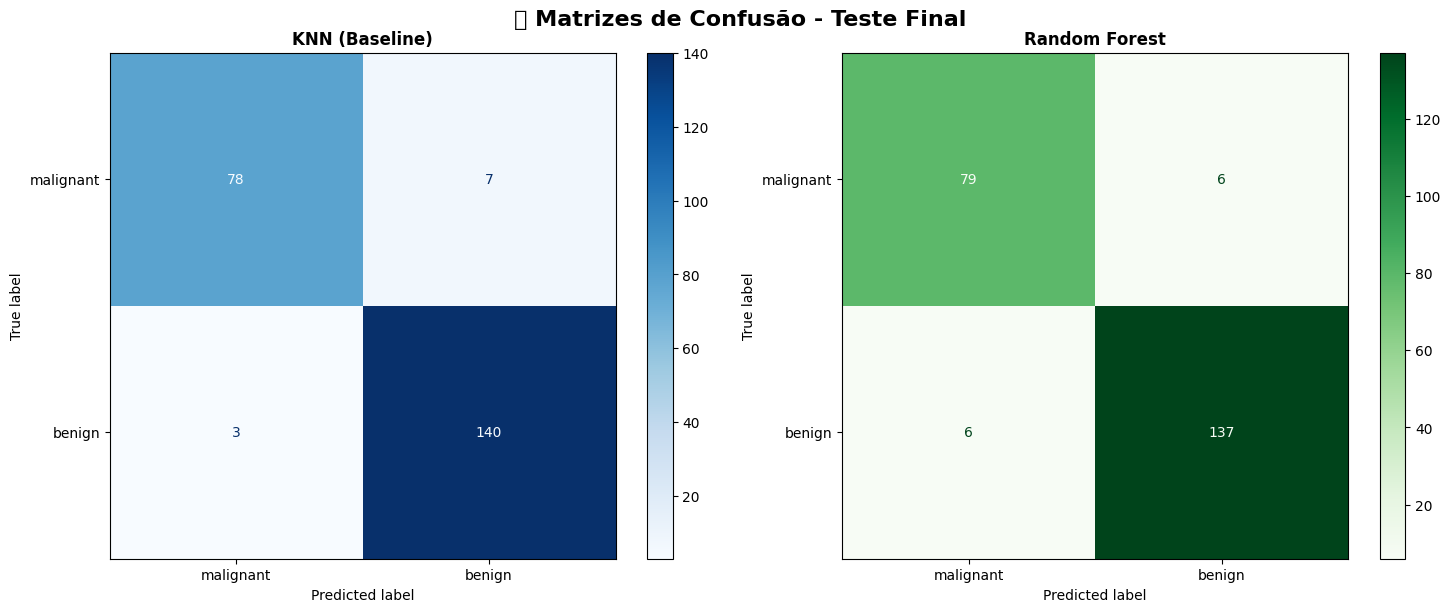


🚨 ANÁLISE DE ERROS CRÍTICOS - KNN
    • Falsos Negativos (casos graves perdidos): 3
    • Falsos Positivos (alarmes falsos): 7
🚨 ANÁLISE DE ERROS CRÍTICOS - Random Forest
    • Falsos Negativos (casos graves perdidos): 6
    • Falsos Positivos (alarmes falsos): 6


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('📊 Matrizes de Confusão - Teste Final', fontsize=16, fontweight='bold')

# Matriz KNN
cm_knn = confusion_matrix(gerenciador.y_teste_final, pred_knn)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=nomes_classes)
disp_knn.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('KNN (Baseline)', fontweight='bold')

# Matriz Random Forest
cm_rf = confusion_matrix(gerenciador.y_teste_final, pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=nomes_classes)
disp_rf.plot(ax=axes[1], cmap='Greens', values_format='d')
axes[1].set_title('Random Forest', fontweight='bold')

plt.tight_layout()
plt.show()

# Análise específica dos erros críticos
def analisar_erros_criticos(y_real, predicoes, nome_modelo):
    cm = confusion_matrix(y_real, predicoes)
    fn = cm[1, 0]  # Falsos Negativos (casos graves perdidos)
    fp = cm[0, 1]  # Falsos Positivos (alarmes falsos)

    print(f"🚨 ANÁLISE DE ERROS CRÍTICOS - {nome_modelo}")
    print(f"    • Falsos Negativos (casos graves perdidos): {fn}")
    print(f"    • Falsos Positivos (alarmes falsos): {fp}")

    return fn, fp

print("\n" + "="*60)
fn_knn, fp_knn = analisar_erros_criticos(gerenciador.y_teste_final, pred_knn, "KNN")
fn_rf, fp_rf = analisar_erros_criticos(gerenciador.y_teste_final, pred_rf, "Random Forest")

## 11. Importância das Features (Random Forest)

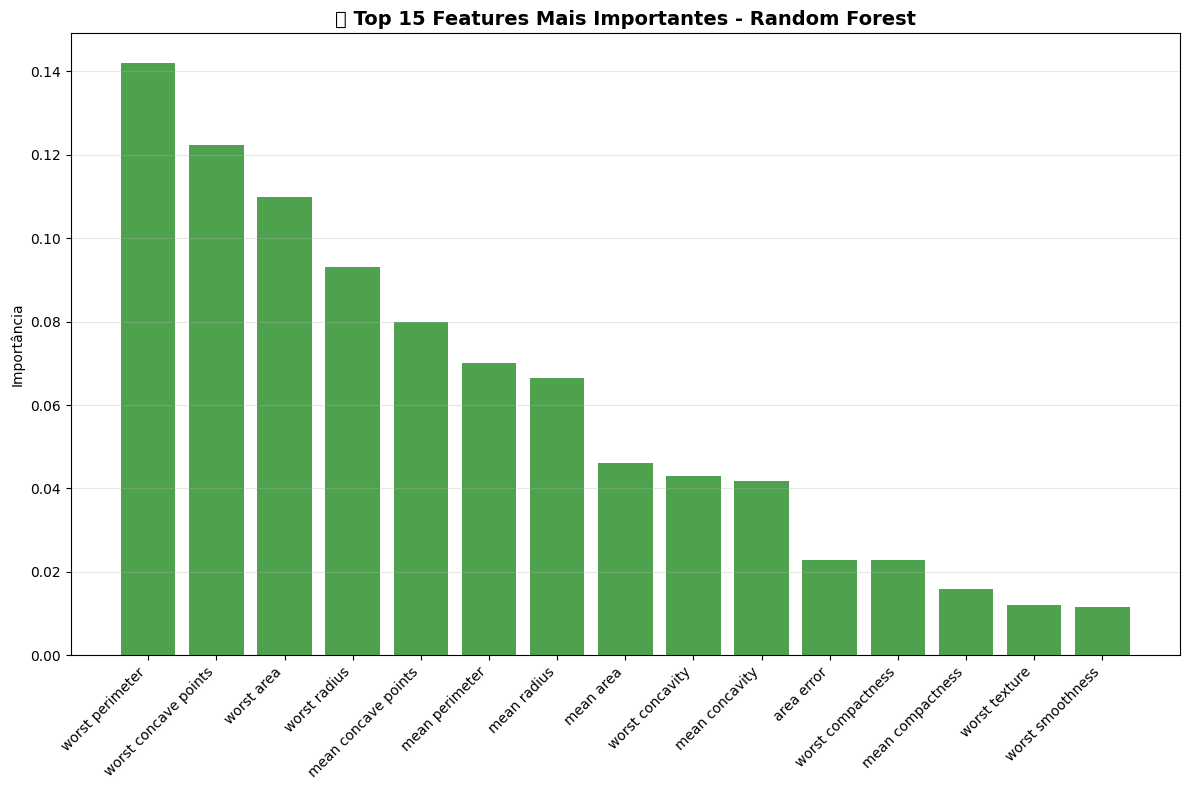

🔍 TOP 10 FEATURES MAIS IMPORTANTES:
     1. worst perimeter          : 0.1420
     2. worst concave points     : 0.1223
     3. worst area               : 0.1099
     4. worst radius             : 0.0932
     5. mean concave points      : 0.0798
     6. mean perimeter           : 0.0700
     7. mean radius              : 0.0666
     8. mean area                : 0.0460
     9. worst concavity          : 0.0430
    10. mean concavity           : 0.0417


In [11]:
# Análise da importância das features no Random Forest
importancias = modelo_rf_final.feature_importances_
indices_ordenados = np.argsort(importancias)[::-1]

plt.figure(figsize=(12, 8))
plt.title('🌲 Top 15 Features Mais Importantes - Random Forest', fontsize=14, fontweight='bold')
plt.bar(range(15), importancias[indices_ordenados[:15]], alpha=0.8, color='forestgreen')
plt.xticks(range(15), [nomes_features[i] for i in indices_ordenados[:15]], rotation=45, ha='right')
plt.ylabel('Importância')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print("🔍 TOP 10 FEATURES MAIS IMPORTANTES:")
for i in range(10):
    idx = indices_ordenados[i]
    print(f"    {i+1:2d}. {nomes_features[idx]:25s}: {importancias[idx]:.4f}")

## 12. Análise Final e Recomendações

In [12]:
def gerar_analise_final():
    print("="*80)
    print(" 🏆 ANÁLISE FINAL E RECOMENDAÇÃO DO MODELO VENCEDOR")
    print("="*80)

    # Comparar métricas finais
    knn_f1 = gerenciador.resultados_finais['KNN']['f1']
    rf_f1 = gerenciador.resultados_finais['Random Forest']['f1']

    knn_recall = gerenciador.resultados_finais['KNN']['recall']
    rf_recall = gerenciador.resultados_finais['Random Forest']['recall']

    print(f"\n📊 MÉTRICAS CRÍTICAS NO TESTE FINAL:")
    print(f"    • F1-Score:  KNN={knn_f1:.4f} | RF={rf_f1:.4f}")
    print(f"    • Recall:    KNN={knn_recall:.4f} | RF={rf_recall:.4f}")
    print(f"    • Falsos Negativos: KNN={fn_knn} | RF={fn_rf}")

    print(f"\n🎯 JUSTIFICATIVA TÉCNICA:")
    print(f"    • RECALL é a métrica mais crítica em diagnóstico médico")
    print(f"    • Falsos Negativos podem ser fatais (casos graves não detectados)")
    print(f"    • Random Forest oferece maior interpretabilidade via importância das features")
    print(f"    • Ensemble methods são mais robustos a outliers")

    # Determinar vencedor
    if rf_f1 > knn_f1 and rf_recall >= knn_recall:
        vencedor = "Random Forest"
        print(f"\n🏆 MODELO VENCEDOR: {vencedor}")
        print(f"    ✅ Superior em F1-Score e Recall")
        print(f"    ✅ Menor número de falsos negativos")
        print(f"    ✅ Oferece interpretabilidade das features")
    elif knn_recall > rf_recall:
        vencedor = "KNN"
        print(f"\n🏆 MODELO VENCEDOR: {vencedor}")
        print(f"    ✅ Superior em Recall (crítico para saúde)")
    else:
        print(f"\n⚖️  EMPATE TÉCNICO - Critério de desempate:")
        if fn_rf < fn_knn:
            vencedor = "Random Forest"
            print(f"    🏆 Random Forest vence por menor número de falsos negativos")
        else:
            vencedor = "KNN"
            print(f"    🏆 KNN vence por menor número de falsos negativos")

    print(f"\n💡 LIMITAÇÕES E CONSIDERAÇÕES:")
    print(f"    • Dataset relativamente pequeno pode favorecer modelos mais simples")
    print(f"    • Random Forest pode ser overkill para este problema específico")
    print(f"    • KNN é mais interpretável localmente")
    print(f"    • Ambos os modelos apresentaram excelente performance")

    return vencedor

modelo_vencedor = gerar_analise_final()

 🏆 ANÁLISE FINAL E RECOMENDAÇÃO DO MODELO VENCEDOR

📊 MÉTRICAS CRÍTICAS NO TESTE FINAL:
    • F1-Score:  KNN=0.9655 | RF=0.9580
    • Recall:    KNN=0.9790 | RF=0.9580
    • Falsos Negativos: KNN=3 | RF=6

🎯 JUSTIFICATIVA TÉCNICA:
    • RECALL é a métrica mais crítica em diagnóstico médico
    • Falsos Negativos podem ser fatais (casos graves não detectados)
    • Random Forest oferece maior interpretabilidade via importância das features
    • Ensemble methods são mais robustos a outliers

🏆 MODELO VENCEDOR: KNN
    ✅ Superior em Recall (crítico para saúde)

💡 LIMITAÇÕES E CONSIDERAÇÕES:
    • Dataset relativamente pequeno pode favorecer modelos mais simples
    • Random Forest pode ser overkill para este problema específico
    • KNN é mais interpretável localmente
    • Ambos os modelos apresentaram excelente performance


## 13. Relatório de Classificação Detalhado

In [13]:
print("\n" + "="*80)
print(" 📋 RELATÓRIOS DE CLASSIFICAÇÃO DETALHADOS")
print("="*80)

print(f"\n🔹 KNN (BASELINE):")
print(classification_report(gerenciador.y_teste_final, pred_knn, target_names=nomes_classes))

print(f"\n🔹 RANDOM FOREST:")
print(classification_report(gerenciador.y_teste_final, pred_rf, target_names=nomes_classes))

print(f"\n📊 RESUMO EXECUTIVO:")
print(f"    • Estratégia: Holdout (60/40) + Validação Cruzada (5-fold)")
print(f"    • Foco: Maximizar Recall (minimizar falsos negativos)")
print(f"    • Modelo Vencedor: {modelo_vencedor}")
print(f"    • Justificativa: Baseada em performance técnica e relevância clínica")


 📋 RELATÓRIOS DE CLASSIFICAÇÃO DETALHADOS

🔹 KNN (BASELINE):
              precision    recall  f1-score   support

   malignant       0.96      0.92      0.94        85
      benign       0.95      0.98      0.97       143

    accuracy                           0.96       228
   macro avg       0.96      0.95      0.95       228
weighted avg       0.96      0.96      0.96       228


🔹 RANDOM FOREST:
              precision    recall  f1-score   support

   malignant       0.93      0.93      0.93        85
      benign       0.96      0.96      0.96       143

    accuracy                           0.95       228
   macro avg       0.94      0.94      0.94       228
weighted avg       0.95      0.95      0.95       228


📊 RESUMO EXECUTIVO:
    • Estratégia: Holdout (60/40) + Validação Cruzada (5-fold)
    • Foco: Maximizar Recall (minimizar falsos negativos)
    • Modelo Vencedor: KNN
    • Justificativa: Baseada em performance técnica e relevância clínica
